# Project 2: Neural networks
NUMN21/FMNN25 Advanced Numerical Algorithms in Python

Recognizing handwritten digits (MNIST) with a 3-layer feedforward network, written with numpy only.
Tasks 1-7.

In [6]:
import gzip
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

## Task 1, 3, 4: the network

Feedforward network with an input, a hidden and an output layer, sigmoid as activation function.
SGD (Task 3) and backpropagation (Task 4) are methods of the same class.

Conventions:
- samples are stored as rows, a mini-batch `X` has shape `(m, n_in)`
- the bias is an extra neuron with constant output 1 in the input and the hidden layer (the "+1" in 784+1 and 30+1).
  So there are no separate bias vectors, the biases are the last column of the weight matrices:
  `W1` has shape `(n_hidden, n_in + 1)` and `W2` has shape `(n_out, n_hidden + 1)`.

For the quadratic loss $C = \frac{1}{2n}\sum_x \|h_w(x) - y\|_2^2$ backprop gives

$$\delta^{(2)} = (a^{(2)} - y) \odot \sigma'(z^{(2)}), \qquad \delta^{(1)} = (W_2^T \delta^{(2)}) \odot \sigma'(z^{(1)}), \qquad \frac{\partial C}{\partial W_l} = \delta^{(l)} (a^{(l-1)})^T$$

(averaged over the mini-batch; the row of $W_2^T$ belonging to the bias neuron is left out in $\delta^{(1)}$).

In [ ]:
def sigmoid(z):
    # equal to 1/(1+exp(-z)), written with tanh so it can't overflow for big |z|
    return 0.5 * (1.0 + np.tanh(0.5 * z))


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def add_bias(A):
    # append the constant bias neuron (a column of ones)
    return np.hstack([A, np.ones((A.shape[0], 1))])


class Network:

    def __init__(self, n_in, n_hidden, n_out, seed=None):
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.rng = np.random.default_rng(seed)

        # random gaussian weights, scaled with 1/sqrt(#inputs to the neuron).
        # With plain N(0,1) and 785 inputs a lot of hidden neurons start out
        # saturated, which makes the first epochs slower.
        self.W1 = self.rng.normal(0.0, 1.0 / np.sqrt(n_in + 1), (n_hidden, n_in + 1))
        self.W2 = self.rng.normal(0.0, 1.0 / np.sqrt(n_hidden + 1), (n_out, n_hidden + 1))

    # forward pass
    def _forward(self, X):
        # also returns the intermediate values, backprop needs them
        Xb = add_bias(X)              # input layer incl. bias neuron
        Z1 = Xb @ self.W1.T           # weighted input of hidden layer
        A1b = add_bias(sigmoid(Z1))   # hidden activations incl. bias neuron
        Z2 = A1b @ self.W2.T          # weighted input of output layer
        A2 = sigmoid(Z2)              # network output
        return Xb, Z1, A1b, Z2, A2

    def feedforward(self, X):
        # h_w(x), X can be one image (784,) or a batch (m, 784)
        X = np.atleast_2d(X)
        return self._forward(X)[-1]

    def predict(self, X):
        return np.argmax(self.feedforward(X), axis=1)

    def evaluate(self, X, labels):
        # number of correctly classified samples
        return int(np.sum(self.predict(X) == labels))

    def loss(self, X, Y):
        # quadratic loss 1/(2n) * sum_x ||h_w(x) - y||^2, Y one-hot
        diff = self.feedforward(X) - Y
        return 0.5 * np.sum(diff ** 2) / X.shape[0]

    # Task 4: backpropagation
    def backprop(self, X, Y):
        # gradient of the quadratic loss (averaged over the batch) - W1 and W2
        m = X.shape[0]
        Xb, Z1, A1b, Z2, A2 = self._forward(X)

        # error in the output layer, delta = dC/dz for C = 1/2 ||a - y||^2
        D2 = (A2 - Y) * sigmoid_prime(Z2)
        # error in the hidden layer. The bias neuron has no incoming weights,
        # so the last column of W2 (the one belonging to it) is left out.
        D1 = (D2 @ self.W2[:, :-1]) * sigmoid_prime(Z1)

        # dC/dw_jk = a_k * delta_j, the matrix product sums over the batch
        grad_W1 = D1.T @ Xb / m
        grad_W2 = D2.T @ A1b / m
        return grad_W1, grad_W2

    # gradients - the input pixels instead of the weights. Same backprop,
    # just one layer further. Not needed for training, only for the attack (Task 7)
    def _backprop_to_input(self, Z1, D2):
        D1 = (D2 @ self.W2[:, :-1]) * sigmoid_prime(Z1)
        return D1 @ self.W1[:, :-1]   # bias column dropped, the constant 1 is not a pixel

    def input_gradient(self, X, Y):
        # dC/dx with C = 1/2 ||h_w(x) - y||^2, one row per sample
        X, Y = np.atleast_2d(X), np.atleast_2d(Y)
        _, Z1, _, Z2, A2 = self._forward(X)
        return self._backprop_to_input(Z1, (A2 - Y) * sigmoid_prime(Z2))

    def output_gradient(self, X, k):
        # dz_k/dx where z_k is the weighted input of output neuron k (before the sigmoid)
        X = np.atleast_2d(X)
        Z1 = self._forward(X)[1]
        D2 = np.zeros((X.shape[0], self.n_out))
        D2[:, k] = 1.0
        return self._backprop_to_input(Z1, D2)

    # Task 3: stochastic gradient descent 
    def sgd(self, training_data, epochs, batch_size, eta, validation_data=None):
        # training_data   : (X, Y) with Y one-hot encoded
        # epochs          : number of full passes through the training data
        # batch_size      : mini-batch size
        # eta             : learning rate
        # validation_data : (X, labels), optional. If given, the accuracy on it
        #                   is printed after each epoch (Task 6)
        X, Y = training_data
        n = X.shape[0]
        history = []

        for epoch in range(1, epochs + 1):
            # new random order every epoch, then walk through it batch by batch
            perm = self.rng.permutation(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start + batch_size]
                gW1, gW2 = self.backprop(X[idx], Y[idx])
                self.W1 -= eta * gW1
                self.W2 -= eta * gW2

            # Task 6: learning success after this epoch
            record = {"epoch": epoch, "train_loss": self.loss(X, Y)}
            msg = f"Epoch {epoch:3d}/{epochs}   training loss: {record['train_loss']:.5f}"
            if validation_data is not None:
                Xv, yv = validation_data
                correct = self.evaluate(Xv, yv)
                record["val_acc"] = correct / len(yv)
                msg += f"   validation: {correct} / {len(yv)} ({100 * record['val_acc']:.2f} %)"
            print(msg)
            history.append(record)

        return history

Quick sanity check of backprop: compare with central finite differences on a tiny random network.

In [8]:
rng = np.random.default_rng(0)
small = Network(6, 4, 3, seed=0)
Xs = rng.random((5, 6))
Ys = np.eye(3)[rng.integers(0, 3, 5)]
gW1, gW2 = small.backprop(Xs, Ys)

h = 1e-6
for name, W, g in [("W1", small.W1, gW1), ("W2", small.W2, gW2)]:
    num = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            w = W[i, j]
            W[i, j] = w + h
            c_plus = small.loss(Xs, Ys)
            W[i, j] = w - h
            c_minus = small.loss(Xs, Ys)
            W[i, j] = w
            num[i, j] = (c_plus - c_minus) / (2 * h)
    print(f"{name}: max difference backprop vs finite diff = {np.max(np.abs(num - g)):.2e}")

W1: max difference backprop vs finite diff = 5.24e-11
W2: max difference backprop vs finite diff = 4.20e-11


## Task 2: reading the MNIST data

`mnist.pkl.gz` from canvas contains a pickled tuple (training, validation, test) with 50000, 10000 and 10000 images.
Each part is a pair (images, labels), every image is a flattened 28x28 picture, i.e. 784 grey values in [0, 1].

In [ ]:
DATA_PATH = "mnist.pkl.gz"


def load_mnist(path):
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rb") as f, warnings.catch_warnings():
        warnings.simplefilter("ignore")
        train, val, test = pickle.load(f, encoding="latin1")

    def convert(part):
        X, y = part
        return X.astype(np.float64), y.astype(np.int64)

    return convert(train), convert(val), convert(test)


def one_hot(labels, n_classes=10):
    # label 3 -> [0,0,0,1,0,0,0,0,0,0]
    labels = np.asarray(labels)
    Y = np.zeros((labels.size, n_classes))
    Y[np.arange(labels.size), labels] = 1.0
    return Y


(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_mnist(DATA_PATH)
Y_train = one_hot(y_train)

print("training:  ", X_train.shape, y_train.shape)
print("validation:", X_val.shape, y_val.shape)
print("test:      ", X_test.shape, y_test.shape)
print("pixel range:", X_train.min(), X_train.max())

training:   (50000, 784) (50000,)
validation: (10000, 784) (10000,)
test:       (10000, 784) (10000,)
pixel range: 0.0 0.99609375


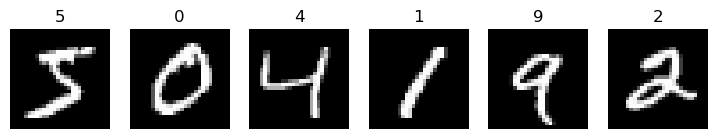

In [ ]:
# first six training images, aiming for 5 0 4 1 9 2 
fig, axes = plt.subplots(1, 6, figsize=(9, 1.8))
for k, ax in enumerate(axes):
    ax.imshow(X_train[k].reshape(28, 28), cmap="gray")
    ax.set_title(y_train[k])
    ax.axis("off")
plt.show()

## Task 5 + 6: training and testing

Input layer 784+1, hidden layer 30+1, output layer 10 neurons, quadratic loss.
The progress is printed after every epoch on the validation set; the test set is only used once at the end.

In [ ]:
N_HIDDEN = 30
EPOCHS = 30
BATCH_SIZE = 10
ETA = 3.0

net = Network(784, N_HIDDEN, 10, seed=42)
print(f"W1 {net.W1.shape}, W2 {net.W2.shape}")

# before training we should be at 10 % correct
print(f"untrained: {net.evaluate(X_val, y_val)} / {len(y_val)} correct on validation data\n")

history = net.sgd((X_train, Y_train), EPOCHS, BATCH_SIZE, ETA,
                  validation_data=(X_val, y_val))

W1 (30, 785), W2 (10, 31)
untrained: 966 / 10000 correct on validation data

Epoch   1/30   training loss: 0.04673   validation: 9464 / 10000 (94.64 %)
Epoch   2/30   training loss: 0.04110   validation: 9516 / 10000 (95.16 %)
Epoch   3/30   training loss: 0.03575   validation: 9556 / 10000 (95.56 %)
Epoch   4/30   training loss: 0.03566   validation: 9557 / 10000 (95.57 %)
Epoch   5/30   training loss: 0.03195   validation: 9575 / 10000 (95.75 %)
Epoch   6/30   training loss: 0.02832   validation: 9615 / 10000 (96.15 %)
Epoch   7/30   training loss: 0.02719   validation: 9613 / 10000 (96.13 %)
Epoch   8/30   training loss: 0.02655   validation: 9607 / 10000 (96.07 %)
Epoch   9/30   training loss: 0.02775   validation: 9595 / 10000 (95.95 %)
Epoch  10/30   training loss: 0.02638   validation: 9604 / 10000 (96.04 %)
Epoch  11/30   training loss: 0.02923   validation: 9553 / 10000 (95.53 %)
Epoch  12/30   training loss: 0.02407   validation: 9616 / 10000 (96.16 %)
Epoch  13/30   training

In [ ]:
correct = net.evaluate(X_test, y_test)
print(f"Test accuracy: {correct} / {len(y_test)} ({100 * correct / len(y_test):.2f} %)")
print(f"Test loss:     {net.loss(X_test, one_hot(y_test)):.5f}")

Test accuracy: 9570 / 10000 (95.70 %)
Test loss:     0.03772


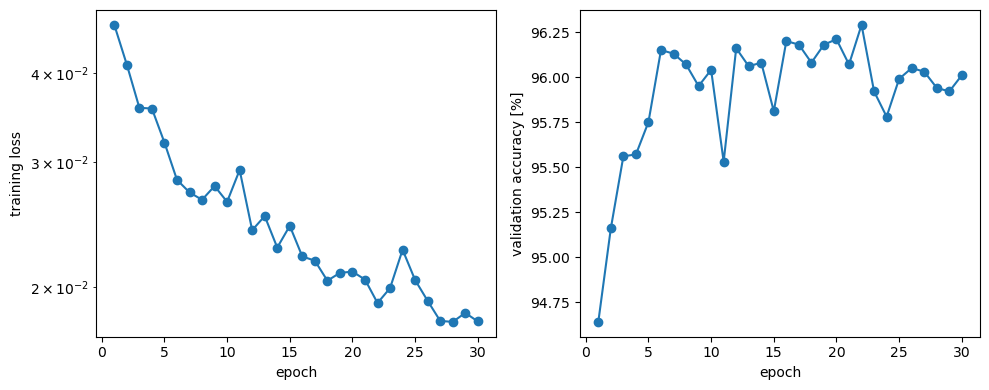

In [13]:
epochs = [h["epoch"] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(epochs, [h["train_loss"] for h in history], "o-")
ax1.set_xlabel("epoch")
ax1.set_ylabel("training loss")
ax1.set_yscale("log")
ax2.plot(epochs, [100 * h["val_acc"] for h in history], "o-")
ax2.set_xlabel("epoch")
ax2.set_ylabel("validation accuracy [%]")
fig.tight_layout()
plt.show()

## Task 7: attacking the trained network

During training we use the gradient of the loss w.r.t. the weights. If we instead take the gradient w.r.t. the
input pixels (backprop one layer further), we know how to change an image so that the output changes the way we
want, while the image still looks almost the same to a human.

**1) FGSM** (fast gradient sign method), untargeted:
$$x_{adv} = \mathrm{clip}_{[0,1]}\big(x + \varepsilon \, \mathrm{sign}(\nabla_x C)\big)$$
every pixel changes by at most $\varepsilon$, in the direction that increases the loss.

**2) Targeted attack**: repeated small signed steps that push up the output neuron of a chosen (wrong) digit until
the network predicts that digit. The total change per pixel is kept in $[-\varepsilon, \varepsilon]$.

For the targeted attack the weighted input $z_{target}$ of the output neuron is used instead of the quadratic loss.
Same reason as the learning slowdown of the quadratic loss: when the output sigmoid is saturated (target output
close to 0), $\sigma'(z)$ is almost zero and the loss gradient is basically useless. We tried both, the $z$ version
got a lot more images to flip.

In [14]:
def fgsm(net, X, labels, eps):
    grad = net.input_gradient(X, one_hot(labels))
    X_adv = X + eps * np.sign(grad)
    return np.clip(X_adv, 0.0, 1.0)   # still has to be a valid image


def targeted_attack(net, x, target, eps=0.3, step=0.01, max_iter=200):
    # returns (adversarial image, number of iterations),
    # iterations is None if the network couldn't be fooled within max_iter
    x = x.reshape(1, -1)
    x_adv = x.copy()
    for it in range(1, max_iter + 1):
        grad = net.output_gradient(x_adv, target)
        x_adv = x_adv + step * np.sign(grad)          # gradient ascent on z_target
        x_adv = np.clip(x_adv, x - eps, x + eps)      # stay close to the original
        x_adv = np.clip(x_adv, 0.0, 1.0)
        if net.predict(x_adv)[0] == target:
            return x_adv[0], it
    return x_adv[0], None


def show(ax, img, title):
    ax.imshow(img.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

### FGSM on the whole test set

eps = 0.00   accuracy on attacked test set:  95.70 %
eps = 0.02   accuracy on attacked test set:  89.49 %
eps = 0.05   accuracy on attacked test set:  81.62 %
eps = 0.08   accuracy on attacked test set:  74.34 %
eps = 0.10   accuracy on attacked test set:  68.75 %
eps = 0.15   accuracy on attacked test set:  53.39 %
eps = 0.20   accuracy on attacked test set:  40.78 %
eps = 0.25   accuracy on attacked test set:  30.77 %
eps = 0.30   accuracy on attacked test set:  24.38 %


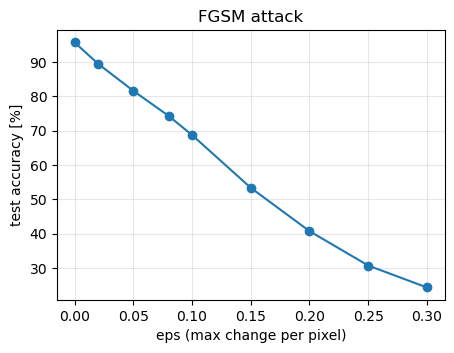

In [15]:
n_test = len(y_test)
eps_values = [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
accs = []
for eps in eps_values:
    X_adv = fgsm(net, X_test, y_test, eps)
    accs.append(100 * net.evaluate(X_adv, y_test) / n_test)
    print(f"eps = {eps:4.2f}   accuracy on attacked test set: {accs[-1]:6.2f} %")

plt.figure(figsize=(5, 3.5))
plt.plot(eps_values, accs, "o-")
plt.xlabel("eps (max change per pixel)")
plt.ylabel("test accuracy [%]")
plt.title("FGSM attack")
plt.grid(alpha=0.3)
plt.show()

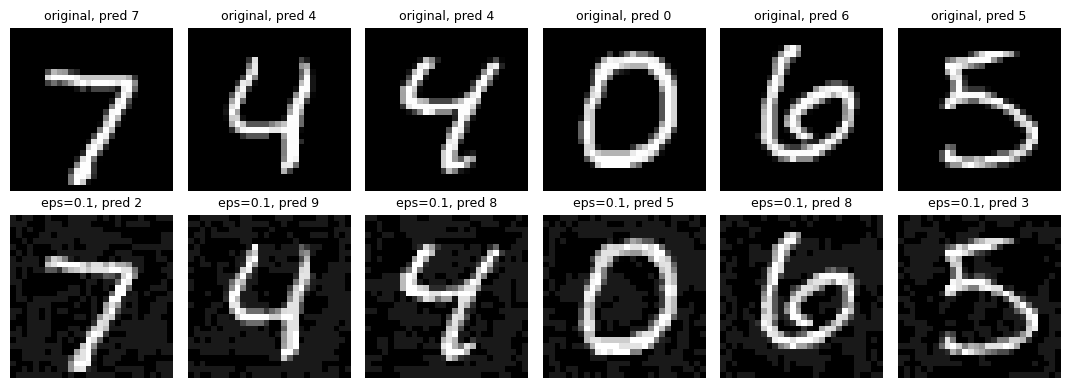

In [16]:
# some examples: original on top, attacked image below
eps = 0.1
X_adv = fgsm(net, X_test, y_test, eps)
pred_clean = net.predict(X_test)
pred_adv = net.predict(X_adv)
# images that were correct before and wrong after the attack
fooled = np.where((pred_clean == y_test) & (pred_adv != y_test))[0][:6]

fig, axes = plt.subplots(2, len(fooled), figsize=(1.8 * len(fooled), 4))
for k, i in enumerate(fooled):
    show(axes[0, k], X_test[i], f"original, pred {pred_clean[i]}")
    show(axes[1, k], X_adv[i], f"eps={eps}, pred {pred_adv[i]}")
fig.tight_layout()
plt.show()

## not needed

### Targeted attack

Take one test image and try to turn it into every other digit.

test image 0, true label 7, network says 7

target 0: reached after  23 steps, output neuron 0 = 0.610, max pixel change 0.23
target 1: not reached
target 2: reached after   7 steps, output neuron 2 = 0.892, max pixel change 0.07
target 3: reached after   8 steps, output neuron 3 = 0.751, max pixel change 0.08
target 4: not reached
target 5: reached after  14 steps, output neuron 5 = 0.395, max pixel change 0.14
target 6: reached after 100 steps, output neuron 6 = 0.023, max pixel change 0.30
target 8: reached after   6 steps, output neuron 8 = 0.898, max pixel change 0.06
target 9: reached after  15 steps, output neuron 9 = 0.879, max pixel change 0.15


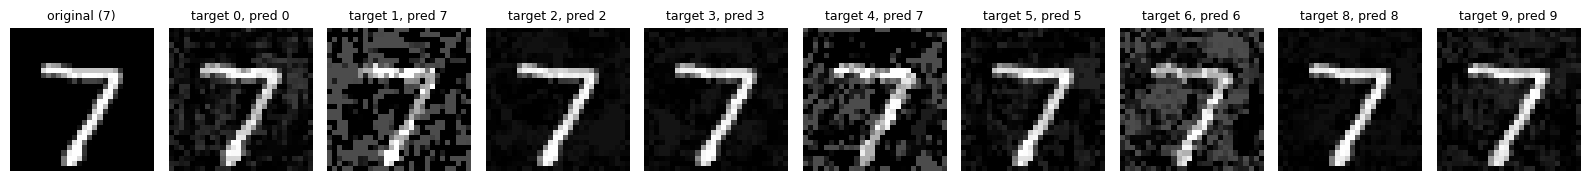

In [17]:
i = 0
x, label = X_test[i], y_test[i]
print(f"test image {i}, true label {label}, network says {net.predict(x)[0]}\n")

fig, axes = plt.subplots(1, 10, figsize=(16, 2.2))
show(axes[0], x, f"original ({label})")
col = 1
for target in range(10):
    if target == label:
        continue
    x_adv, its = targeted_attack(net, x, target)
    out = net.feedforward(x_adv)[0]
    if its is None:
        print(f"target {target}: not reached")
    else:
        print(f"target {target}: reached after {its:3d} steps, "
              f"output neuron {target} = {out[target]:.3f}, "
              f"max pixel change {np.max(np.abs(x_adv - x)):.2f}")
    show(axes[col], x_adv, f"target {target}, pred {net.predict(x_adv)[0]}")
    col += 1
fig.tight_layout()
plt.show()

In [18]:
# success rate on a subset with random wrong targets
rng = np.random.default_rng(0)
idx = rng.choice(n_test, 500, replace=False)
success = 0
for i in idx:
    target = (y_test[i] + rng.integers(1, 10)) % 10   # never the true label
    _, its = targeted_attack(net, X_test[i], target)
    success += its is not None
print(f"success rate on 500 random test images (random wrong target, eps=0.3): "
      f"{100 * success / len(idx):.1f} %")

success rate on 500 random test images (random wrong target, eps=0.3): 90.2 %
